## Step 0: Get your packages in order.

In [2]:
!pip install SimpleITK # This is a special library for visualising medical images.
!pip install medpy # This is a special library for medical image processing and metric computation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=a3a4e72a53a07c3726a4523a1ee9d5e7874561f80df4674ec2ecbc6cd46665bf
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [3]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import sklearn as skl
import albumentations as A
from skimage.transform import resize
import SimpleITK as sitk
import tensorflow as tf
from tensorflow import keras
import medpy
from medpy.metric.binary import hd, hd95, dc
from keras import layers, Model
from keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint

# 1. Download and Load the Training, Test and Validation Datasets

Data source: [BOston Neonatal Brain Injury Data](https://zenodo.org/records/10602767)


### *A Note on the Training Data* ###

The data consists of a special type of preprocessed MRI images, known as ADC maps.

*ADC: Apparent Diffusion Coefficient*
- It is a measure of the magnitude of diffusion (or movement) of water molecules across brain tissues.

- This molecular movement can be restricted due to structural damage in the brain, such as tumours or lesions.

- Areas where this happens tend to appear noticeably darker than surrounding areas on MRI images.

- These darker areas can help doctors to determine where these lesions or tumours could be located on the brain.

The ADC maps in the dataset have been categorised into three groups.

The first group contains raw, unedited, unprocessed images.

The second group comprises ADC maps that have undergone Z-score normalisation. This has been done to account for the fact that, under healthy conditions, different areas of the brain have different movement patterns of water molecules.

 So, Z-score normalisation is required to ensure that the movement of water molecules is compared across brain regions, according to each specific region's healthy baseline for molecular movement.

 The third group comprises binary masks of the images in which the brain lesions have been manually annotated by trained physicians.

 More information can be found on these pages:

 [Bao et al., 2023](https://www.biorxiv.org/content/10.1101/2023.06.30.546841v1.full)

 [Radiopaedia - Apparent Diffusion Coefficient](https://radiopaedia.org/articles/apparent-diffusion-coefficient-1)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/train_data.zip
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/val_data.zip
#!tar -xvf /content/drive/MyDrive/CSE602_Project_Data/atlases.tar.gz
#!unzip -q /content/drive/MyDrive/CSE602_Project_Data/test_data.zip

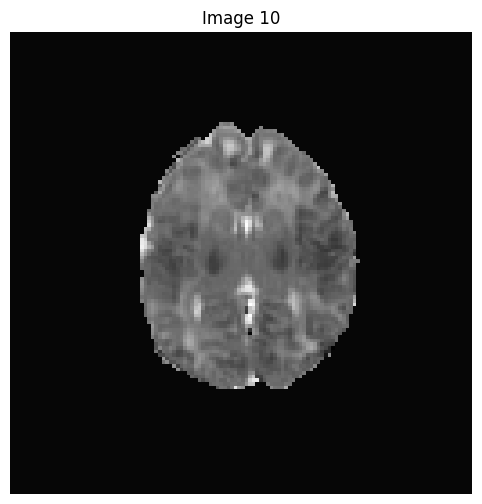

(128, 128, 23)


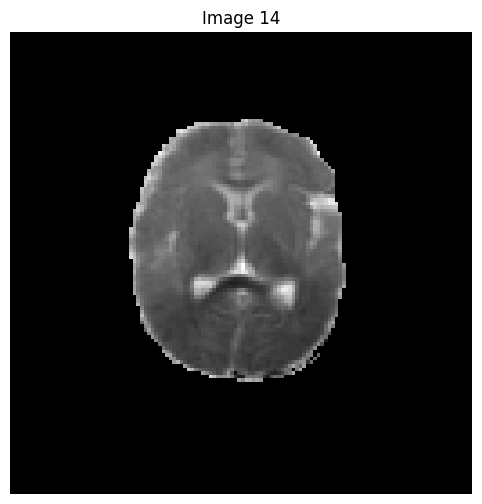

(128, 128, 23)


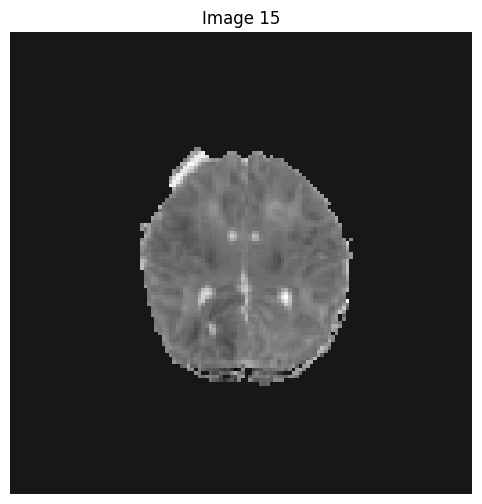

(128, 128, 23)


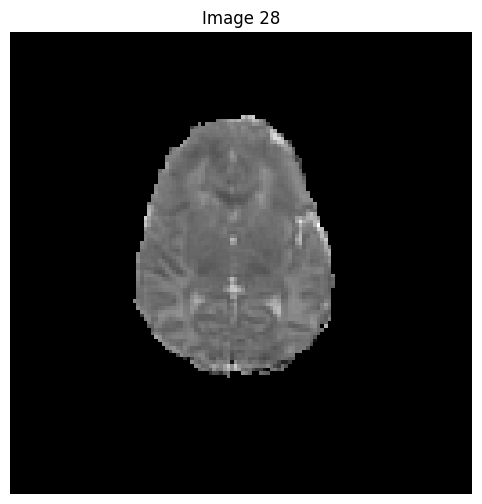

(128, 128, 23)


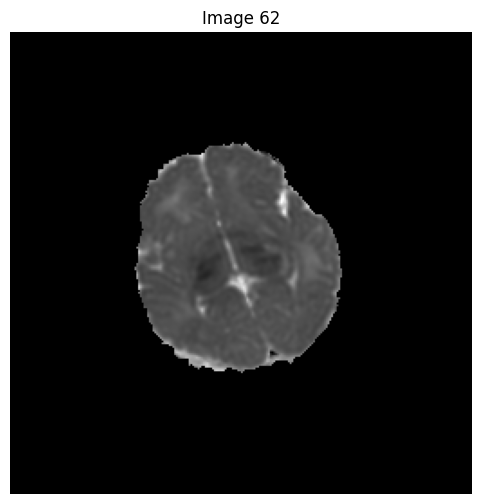

(256, 256, 19)


In [ ]:
#Some basic EDA; we read in and visualise the first five raw ADC maps to get a glimpse of the data we'll be dealing with.


train_dir = '/content/BONBID2023_Train'

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/1ADC_ss/MGHNICU_0{i}-VISIT_01-ADC_ss.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

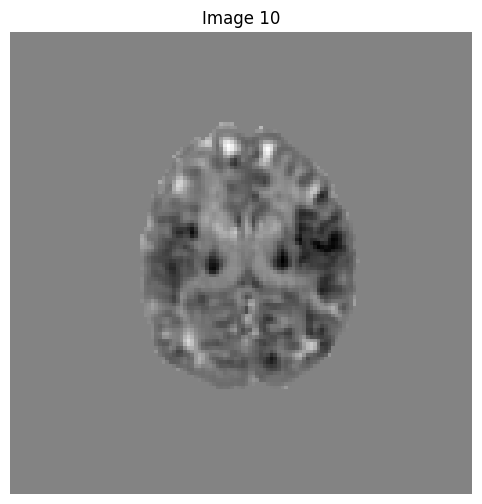

(128, 128, 23)


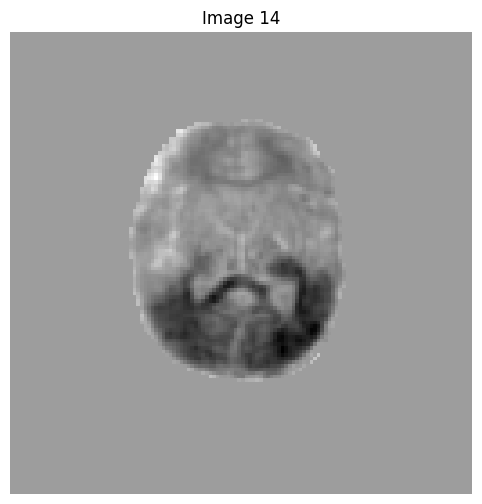

(128, 128, 23)


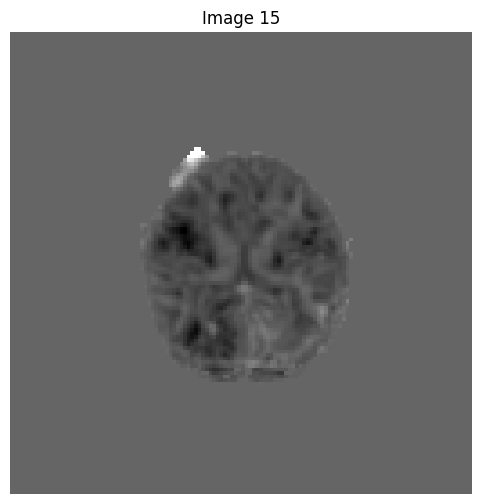

(128, 128, 23)


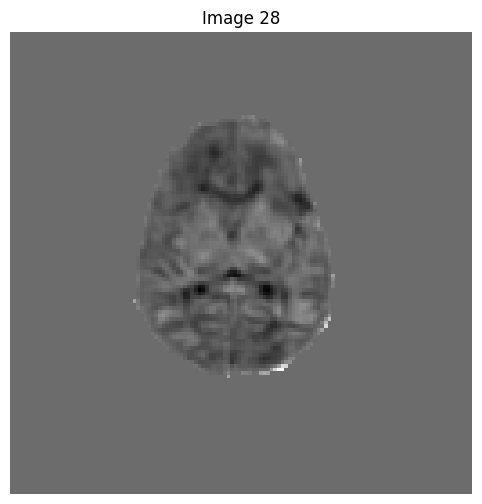

(128, 128, 23)


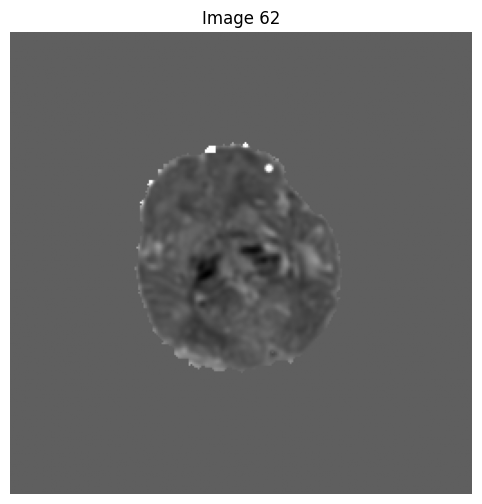

(256, 256, 19)


In [ ]:
# We do the same for the Z-score normalised ADC maps...

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/2Z_ADC/Zmap_MGHNICU_0{i}-VISIT_01-ADC_smooth2mm_clipped10.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

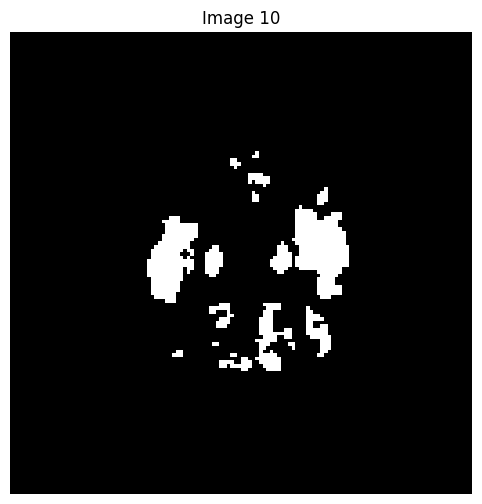

(128, 128, 23)


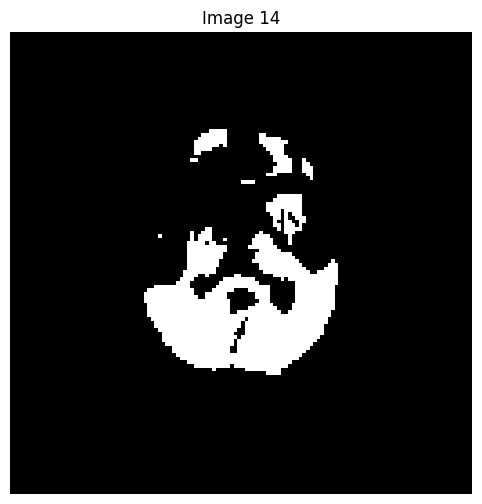

(128, 128, 23)


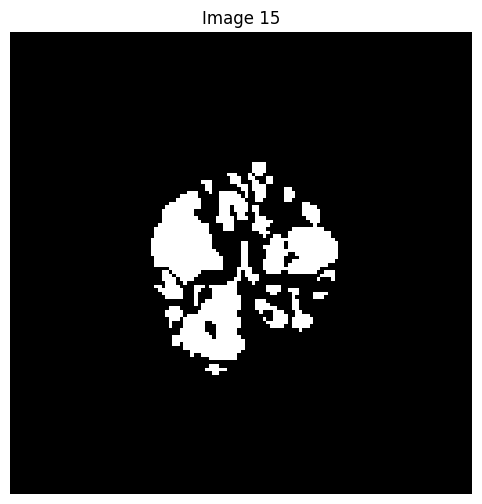

(128, 128, 23)


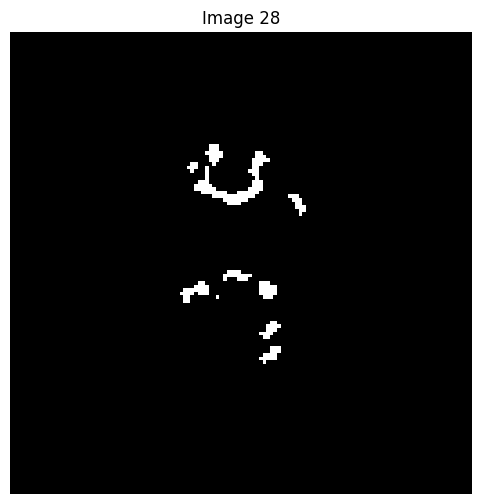

(128, 128, 23)


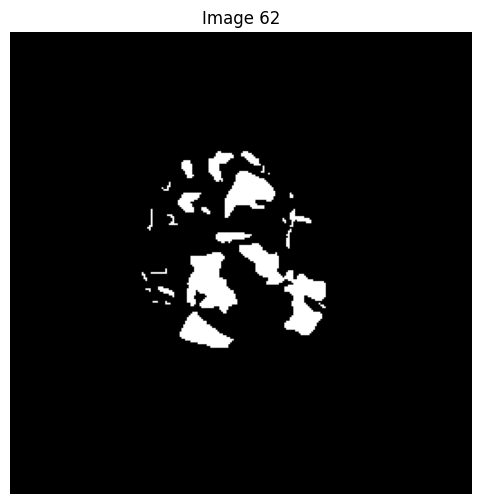

(256, 256, 19)


In [ ]:
# ...and for the binary image masks with brain lesions annotated by experts.

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/3LABEL/MGHNICU_0{i}-VISIT_01_lesion.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

##2. Read in and Preprocess the Training and Validation Data

In order to build a model that uses multimodal data, using the ADC and ZADC maps as two separate modalities, we need to stack the ADC and ZADC maps to obtain the final training and validation datasets.

In [4]:
adc_dir = '/content/BONBID2023_Train/1ADC_ss'
zadc_dir = '/content/BONBID2023_Train/2Z_ADC'
mask_dir = '/content/BONBID2023_Train/3LABEL'

all_adc_files = os.listdir(adc_dir)
pids = []

for filename in all_adc_files:
    if filename.startswith('MGHNICU_'):
        pid = filename.split('-ADC')[0]
        pids.append(pid)

pids = list(set(pids))

random.seed(42)
random.shuffle(pids)

train_idx = int(len(pids) * 0.85)
train_pids = pids[:train_idx]
test_pids = pids[train_idx:]

print(f"Total Patients: {len(pids)} | Train: {len(train_pids)} | Test: {len(test_pids)}")

Total Patients: 85 | Train: 72 | Test: 13


In [5]:
def split_train_and_test(pid_list, target_shape=(23, 128, 128)):
    X_list = []
    y_list = []

    for pid in pid_list:
        adc_path = os.path.join(adc_dir, f"{pid}-ADC_ss.mha")
        zadc_path = os.path.join(zadc_dir, f"Zmap_{pid}-ADC_smooth2mm_clipped10.mha")
        mask_path = os.path.join(mask_dir, f"{pid}_lesion.mha")

        adc_arr = sitk.GetArrayFromImage(sitk.ReadImage(adc_path))
        zadc_arr = sitk.GetArrayFromImage(sitk.ReadImage(zadc_path))
        mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(mask_path))

        if adc_arr.shape != target_shape:
            adc_arr = resize(adc_arr, target_shape, order=1, preserve_range=True, anti_aliasing=True)
            zadc_arr = resize(zadc_arr, target_shape, order=1, preserve_range=True, anti_aliasing=True)
            mask_arr = resize(mask_arr, target_shape, order=0, preserve_range=True, anti_aliasing=False)

        patient_features = np.stack([adc_arr, zadc_arr], axis=-1)

        X_list.append(patient_features)
        y_list.append(mask_arr)

    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_train, y_train = split_train_and_test(train_pids)
X_test, y_test = split_train_and_test(test_pids)

y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

In [8]:
# We now prepare to load in the validation data.

val_adc_dir = '/content/1ADC_ss'
val_zadc_dir = '/content/2Z_ADC'
val_mask_dir = '/content/3LABEL'

val_adc_files = os.listdir(val_adc_dir)
val_pids = []
for filename in val_adc_files:
    if filename.startswith('MGHNICU_'):
        pid = filename.split('-ADC')[0]
        val_pids.append(pid)

In [9]:
# We define a helper function to load in and resize the validation data.
# A separate validation dataset is already available, and so does not need to be created from the training dataset.

def load_val_data(pid_list, target_shape=(23, 128, 128)):
    X_list = []
    y_list = []

    for pid in pid_list:
        adc_path = os.path.join(val_adc_dir, f"{pid}-ADC_ss.mha")
        zadc_path = os.path.join(val_zadc_dir, f"Zmap_{pid}-ADC_smooth2mm_clipped10.mha")
        mask_path = os.path.join(val_mask_dir, f"{pid}_lesion.mha")

        adc_arr = sitk.GetArrayFromImage(sitk.ReadImage(adc_path))
        zadc_arr = sitk.GetArrayFromImage(sitk.ReadImage(zadc_path))
        mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(mask_path))

        if adc_arr.shape != target_shape:
            adc_arr = resize(adc_arr, target_shape, order=1, preserve_range=True, anti_aliasing=True)
            zadc_arr = resize(zadc_arr, target_shape, order=1, preserve_range=True, anti_aliasing=True)
            mask_arr = resize(mask_arr, target_shape, order=0, preserve_range=True, anti_aliasing=False)

        patient_features = np.stack([adc_arr, zadc_arr], axis=-1)

        X_list.append(patient_features)
        y_list.append(mask_arr)

    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_val, y_val_raw = load_val_data(val_pids)
y_val = np.expand_dims(y_val_raw, axis=-1)

In [15]:
print(X_train.shape)
print(y_train.shape)

(1656, 128, 128, 2)
(1656, 128, 128, 1)


In [16]:
print(X_test.shape)
print(y_test.shape)

(299, 128, 128, 2)
(299, 128, 128, 1)


In [11]:
print(X_val.shape)
print(y_val.shape)

(92, 128, 128, 2)
(92, 128, 128, 1)


##3. Build and Train the Model

The chosen model architecture is the [2.5D Transformer Backbone U-Net Model](https://www.mdpi.com/2076-3425/15/8/778#:~:text=To%20evaluate%20the%20effectiveness%20of,diagnostic%20tools%20in%20clinical%20settings.).


This architecture has been chosen as it has achieved a Dice score of 0.8153 while segmented brain lesions in stroke patients.


The detailed rationale for this choice of architecture may be found in the explanatory project idea presentation which has been uploaded to this repository.


The following model architecture is a baseline architecture to implement this model. Parameters will be edited according to the model's performance on initial runs.

In [ ]:
def transformer_block(x, num_heads = 4, key_dim = 128, mlp_dim = 256, dropout = 0.1):
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    mlp_out = layers.Dense(mlp_dim, activation='gelu')(x)
    mlp_out = layers.Dense(x.shape[-1])(mlp_out)
    mlp_out = layers.Dropout(dropout)(mlp_out)
    x = layers.Add()([x, mlp_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

In [ ]:
def build_2_5d_transunet(input_shape=(128, 128, 2), num_classes = 1):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(128, 3, padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)

    c1 = layers.Conv2D(128, 3, padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)

    c2 = layers.Conv2D(128, 3, padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D()(c2)

    shape = p2.shape
    patch_dim = shape[-1]
    flattened = layers.Reshape((shape[1] * shape[2], patch_dim))(p2)

    t1 = transformer_block(flattened)
    t2 = transformer_block(t1)

    t_feat = layers.Reshape((shape[1], shape[2], patch_dim))(t2)
    t_feat = layers.Conv2D(128, 3, padding='same', activation='relu')(t_feat)

    u_block1 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(t_feat)
    u_block1 = layers.concatenate([u_block1, c2])

    conv_block1 = layers.Conv2D(128, 3, padding='same')(u_block1)
    conv_block1 = layers.BatchNormalization()(conv_block1)
    conv_block1 = layers.Activation('relu')(conv_block1)

    conv_block1 = layers.Conv2D(128, 3, padding='same')(conv_block1)
    conv_block1 = layers.BatchNormalization()(conv_block1)
    conv_block1 = layers.Activation('relu')(conv_block1)

    u_block2 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(conv_block1)
    u_block2 = layers.concatenate([u_block2, c1])

    conv_block2 = layers.Conv2D(128, 3, padding='same')(u_block2)
    conv_block2 = layers.BatchNormalization()(conv_block2)
    conv_block2 = layers.Activation('relu')(conv_block2)

    conv_block2 = layers.Conv2D(128, 3, padding='same')(conv_block2)
    conv_block2 = layers.BatchNormalization()(conv_block2)
    conv_block2 = layers.Activation('relu')(conv_block2)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(conv_block2)

    return Model(inputs, outputs)

In [ ]:
model = build_2_5d_transunet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,432 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    147,584 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1024, 128) │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 128) │    263,808 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]   

 Total params: 2,274,049 (8.67 MB)

 Trainable params: 2,272,001 (8.67 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# We need to define a helper function to calculate the Dice coefficient as Keras does not provide this as a built-in metric.
def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

In [ ]:
# We also require a hybrid loss function to account for class imbalance in the training set.
# This helper function combines the Dice Loss and Focal Loss.

dice_loss = keras.losses.Dice()
bce_focal_loss = keras.losses.BinaryFocalCrossentropy()

def hybrid_loss(y_true, y_pred):
  dice = dice_loss(y_true, y_pred)
  focal = bce_focal_loss(y_true, y_pred)
  return dice + focal

In [ ]:
model.compile(optimizer = keras.optimizers.AdamW(learning_rate = 0.0001, weight_decay = 0.01), loss = hybrid_loss, metrics = [dice_coef, 'accuracy'])

In [ ]:
# We create a log file for our model parameters for reproducibility and experiment tracking.

hyper_params = {
    "run_name": "run_02",
    "learning_rate": 0.0001,
    "weight_decay": 0.01,
    "batch_size": 16,
    "epochs": 100,
    "patience": 20
}

df = pd.DataFrame([hyper_params])
df.to_csv('/content/run_02_hyperparameters.csv', index = False)

In [ ]:
# We train the model, ensuring to stop training if the weights stop improving after a set number of epochs.

csv_logger = CSVLogger('training_log_run_2.csv', append = True)
early_stopper = EarlyStopping(patience = 20, monitor = 'val_loss', restore_best_weights = True)
model_checkpoint = ModelCheckpoint('/content/run_2.keras', monitor = 'val_loss', save_best_only = True)

history = model.fit(X_train, y_train, epochs = 100, batch_size = 16, validation_data = (X_val, y_val), callbacks = [early_stopper, csv_logger, model_checkpoint])

Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8488 - dice_coef: 0.0357 - loss: 1.0521

123/123 ━━━━━━━━━━━━━━━━━━━━ 122s 628ms/step - accuracy: 0.9469 - dice_coef: 0.0556 - loss: 0.9849 - val_accuracy: 0.9838 - val_dice_coef: 0.0180 - val_loss: 1.0266
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9840 - dice_coef: 0.1166 - loss: 0.8993

123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 374ms/step - accuracy: 0.9863 - dice_coef: 0.1352 - loss: 0.8807 - val_accuracy: 0.9923 - val_dice_coef: 0.1133 - val_loss: 0.8918
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 365ms/step - accuracy: 0.9916 - dice_coef: 0.2530 - loss: 0.7604 - val_accuracy: 0.9621 - val_dice_coef: 0.1724 - val_loss: 0.9145
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9935 - dice_coef: 0.3480 - loss: 0.6661

123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.9940 - dice_coef: 0.3677 - loss: 0.6464 - val_accuracy: 0.9700 - val_dice_coef: 0.2297 - val_loss: 0.8468
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 365ms/step - accuracy: 0.9947 - dice_coef: 0.4469 - loss: 0.5692 - val_accuracy: 0.9026 - val_dice_coef: 0.1290 - val_loss: 1.5200
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9952 - dice_coef: 0.5240 - loss: 0.4896

123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9955 - dice_coef: 0.5131 - loss: 0.5000 - val_accuracy: 0.9956 - val_dice_coef: 0.2677 - val_loss: 0.7367
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9952 - dice_coef: 0.5311 - loss: 0.4835

...

123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 368ms/step - accuracy: 0.9970 - dice_coef: 0.7119 - loss: 0.3010 - val_accuracy: 0.9944 - val_dice_coef: 0.5934 - val_loss: 0.4198
Epoch 28/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 366ms/step - accuracy: 0.9971 - dice_coef: 0.7246 - loss: 0.2909 - val_accuracy: 0.9954 - val_dice_coef: 0.3881 - val_loss: 0.6288
Epoch 29/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9970 - dice_coef: 0.7057 - loss: 0.3093

123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.9971 - dice_coef: 0.7132 - loss: 0.2961 - val_accuracy: 0.9949 - val_dice_coef: 0.6017 - val_loss: 0.4078
Epoch 30/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9969 - dice_coef: 0.7506 - loss: 0.2643

123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9972 - dice_coef: 0.7419 - loss: 0.2716 - val_accuracy: 0.9967 - val_dice_coef: 0.6480 - val_loss: 0.3565
Epoch 31/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 366ms/step - accuracy: 0.9970 - dice_coef: 0.7088 - loss: 0.3030 - val_accuracy: 0.9785 - val_dice_coef: 0.3574 - val_loss: 0.7323
Epoch 32/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9973 - dice_coef: 0.7240 - loss: 0.2872 - val_accuracy: 0.9735 - val_dice_coef: 0.3262 - val_loss: 0.8117
Epoch 33/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9972 - dice_coef: 0.7427 - loss: 0.2719 - val_accuracy: 0.9946 - val_dice_coef: 0.5935 - val_loss: 0.4152
Epoch 34/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 366ms/step - accuracy: 0.9971 - dice_coef: 0.7192 - loss: 0.2929 - val_accuracy: 0.9966 - val_dice_coef: 0.5792 - val_loss: 0.4297
Epoch 35/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9970 - dice_coef: 0.6852 - loss: 0.3298 - val_accuracy: 0

123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.9974 - dice_coef: 0.7272 - loss: 0.2854 - val_accuracy: 0.9968 - val_dice_coef: 0.6553 - val_loss: 0.3497
Epoch 50/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9973 - dice_coef: 0.7337 - loss: 0.2748 - val_accuracy: 0.9964 - val_dice_coef: 0.4862 - val_loss: 0.5251
Epoch 51/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9974 - dice_coef: 0.7494 - loss: 0.2621 - val_accuracy: 0.9969 - val_dice_coef: 0.6019 - val_loss: 0.4057
Epoch 52/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9974 - dice_coef: 0.7565 - loss: 0.2544 - val_accuracy: 0.9966 - val_dice_coef: 0.6266 - val_loss: 0.3806
Epoch 53/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9972 - dice_coef: 0.7331 - loss: 0.2821 - val_accuracy: 0.9963 - val_dice_coef: 0.6446 - val_loss: 0.3626
Epoch 54/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 368ms/step - accuracy: 0.9974 - dice_coef: 0.7463 - loss: 0.2640 - val_accuracy: 0

123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9973 - dice_coef: 0.7293 - loss: 0.2797 - val_accuracy: 0.9963 - val_dice_coef: 0.6633 - val_loss: 0.3424
Epoch 65/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.9972 - dice_coef: 0.7263 - loss: 0.2866 - val_accuracy: 0.9945 - val_dice_coef: 0.6023 - val_loss: 0.4098
Epoch 66/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 368ms/step - accuracy: 0.9974 - dice_coef: 0.7640 - loss: 0.2477 - val_accuracy: 0.9904 - val_dice_coef: 0.4891 - val_loss: 0.5398
Epoch 67/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9975 - dice_coef: 0.7551 - loss: 0.2553 - val_accuracy: 0.9967 - val_dice_coef: 0.6235 - val_loss: 0.3804
Epoch 68/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9974 - dice_coef: 0.7469 - loss: 0.2617 - val_accuracy: 0.9956 - val_dice_coef: 0.6495 - val_loss: 0.3555
Epoch 69/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 369ms/step - accuracy: 0.9975 - dice_coef: 0.7618 - loss: 0.2466 - val_accuracy: 0

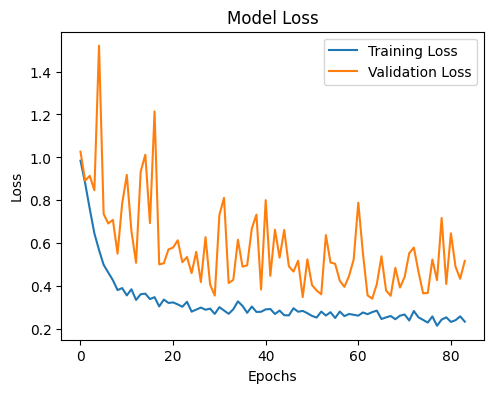

In [ ]:
# We plot the training and validation loss to ensure there is no overfitting or underfitting, and no vanishing or exploding gradients.

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

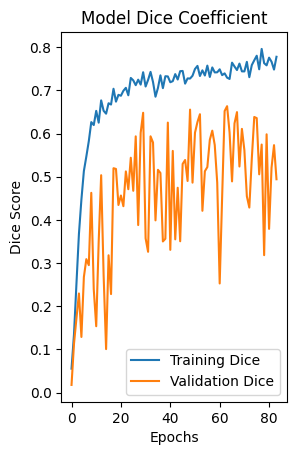

In [ ]:
# We also plot the dice coefficients for the training and validation datasets to assess model performance.

plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.title('Model Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.show()

In [ ]:
# We evaluate the model on the validation data
# and calculate the DSC, Hausdorff distance and 95th percentile Hausdorff distance.
# This tells us how good our model currently is, and gives us an idea of
# how much improvement is required.

y_pred_probs = model.predict(X_val)
y_pred_bin = (y_pred_probs > 0.5).astype(int)
y_val_bin = y_val.astype(int)

global_dice = dc(y_pred_bin, y_val_bin)
print(f"Global Validation DSC: {global_dice:.4f}")

hd_list = []
hd95_list = []
slice_dice_list = []

for i in range(len(y_val_bin)):
    true_slice = y_val_bin[i]
    pred_slice = y_pred_bin[i]

    if np.sum(true_slice) == 0 and np.sum(pred_slice) == 0:
        slice_dice_list.append(1.0)
    else:
        slice_dice_list.append(dc(pred_slice, true_slice))

    if np.sum(true_slice) > 0 and np.sum(pred_slice) > 0:
        try:
            hd_val = hd(pred_slice, true_slice, voxelspacing=None)
            hd95_val = hd95(pred_slice, true_slice, voxelspacing=None)

            hd_list.append(hd_val)
            hd95_list.append(hd95_val)
        except Exception as e:
            pass

print(f"Average Slice-wise DSC: {np.mean(slice_dice_list):.4f}")

if hd_list:
    print(f"Average HD: {np.mean(hd_list):.2f} mm")
    print(f"Average HD95: {np.mean(hd95_list):.2f} mm")
else:
    print("No matching positive slices found to calculate HD/HD95.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step
Global Validation DSC: 0.8921
Average Slice-wise DSC: 0.6402
Average HD: 11.51 mm
Average HD95: 7.69 mm
